In [1]:
!gsutil cp gs://dbm-dat-dataset/emotion_dataset.zip /kaggle/working/

Copying gs://dbm-dat-dataset/emotion_dataset.zip...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").


Operation completed over 1 objects/1.0 GiB.                                      


In [2]:
!unzip -qq /kaggle/working/emotion_dataset.zip -d /kaggle/working/SER_data_archive

In [3]:
# ============================================================
# 3D CNN + BiLSTM + Attention for Speech Emotion Recognition
# ============================================================
# Dataset: SAVEE + RAVDESS + TESS (hybrid)
# Audio: 16kHz, mono, pre-processed
# Platform: Kaggle Notebooks
# ============================================================
# ====== SETUP & IMPORTS ======
import os
import time
import gc
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

# ====== PATHS ======
DATA_ROOT = '/kaggle/working/SER_data_archive/output'

TRAIN_CSV = os.path.join(DATA_ROOT, 'train.csv')
VAL_CSV   = os.path.join(DATA_ROOT, 'val.csv')
TEST_CSV  = os.path.join(DATA_ROOT, 'test.csv')

TRAIN_DIR = os.path.join(DATA_ROOT, 'train_data')
VAL_DIR   = os.path.join(DATA_ROOT, 'val_data')
TEST_DIR  = os.path.join(DATA_ROOT, 'test_data')

# Test riêng từng dataset
RAVDESS_TEST_CSV = os.path.join(DATA_ROOT, 'ravdess_test.csv')
RAVDESS_TEST_DIR = os.path.join(DATA_ROOT, 'ravdess_test_data')

SAVEE_TEST_CSV = os.path.join(DATA_ROOT, 'savee_test.csv')
SAVEE_TEST_DIR = os.path.join(DATA_ROOT, 'savee_test_data')

TESS_TEST_CSV = os.path.join(DATA_ROOT, 'tess_test.csv')
TESS_TEST_DIR = os.path.join(DATA_ROOT, 'tess_test_data')

FEATURE_DIR = '/kaggle/working/features'

print("=" * 70)
print("SPEECH EMOTION RECOGNITION - 3D CNN + BiLSTM + Attention")
print("=" * 70)

SPEECH EMOTION RECOGNITION - 3D CNN + BiLSTM + Attention


In [4]:
# ====== WANDB SETUP ======
!pip install -q wandb

import wandb
# Dang nhap wandb
os.environ["WANDB_API_KEY"] = "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"
wandb.login()

print("✅ WandB ready")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: dokhang307 (minhtrietsonny-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB ready


In [5]:
# ====== LOAD METADATA ======

df_train = pd.read_csv(TRAIN_CSV)
df_val   = pd.read_csv(VAL_CSV)
df_test  = pd.read_csv(TEST_CSV)

# Label mapping
label_mapping = {
    'neutral': 0, 'happy': 1, 'sad': 2, 'angry': 3,
    'fear': 4, 'disgust': 5, 'surprise': 6
}
NUM_CLASSES = 7
EMOTION_LABELS = list(label_mapping.keys())

def prepare_df(df, audio_dir, split_name):
    """Fix filepath to Kaggle paths and encode labels"""
    # Build correct path from filename
    df = df.copy()
    df['audio_path'] = df['filename'].apply(lambda f: os.path.join(audio_dir, f))
    df['label_idx'] = df['emotion'].map(label_mapping)

    # Check for unmapped emotions
    unmapped = df[df['label_idx'].isna()]['emotion'].unique()
    if len(unmapped) > 0:
        print(f"  [{split_name}] Unmapped emotions: {unmapped}")
        df = df.dropna(subset=['label_idx'])
        df['label_idx'] = df['label_idx'].astype(int)

    # Check file existence
    exists = df['audio_path'].apply(os.path.exists)
    print(f" [{split_name}] Files found: {exists.sum()}/{len(df)}")

    if (~exists).sum() > 0:
        missing = df[~exists]['audio_path'].iloc[:3].tolist()
        print(f"   Missing examples: {missing}")
        df = df[exists].reset_index(drop=True)

    return df

df_train = prepare_df(df_train, TRAIN_DIR, 'TRAIN')
df_val   = prepare_df(df_val,   VAL_DIR,   'VAL')
df_test  = prepare_df(df_test,  TEST_DIR,  'TEST')

print(f"\n Dataset Summary:")
print(f"   Train: {len(df_train):,} samples")
print(f"   Val:   {len(df_val):,} samples")
print(f"   Test:  {len(df_test):,} samples")
print(f"\n Emotion distribution (Train):")
for emotion, count in df_train['emotion'].value_counts().sort_index().items():
    print(f"   - {emotion:<12s}: {count:5d} ({100*count/len(df_train):5.1f}%)")

 [TRAIN] Files found: 14236/14236
 [VAL] Files found: 484/484
 [TEST] Files found: 484/484

 Dataset Summary:
   Train: 14,236 samples
   Val:   484 samples
   Test:  484 samples

 Emotion distribution (Train):
   - angry       :  2048 ( 14.4%)
   - disgust     :  2048 ( 14.4%)
   - fear        :  2048 ( 14.4%)
   - happy       :  2044 ( 14.4%)
   - neutral     :  1952 ( 13.7%)
   - sad         :  2048 ( 14.4%)
   - surprise    :  2048 ( 14.4%)


In [6]:
# ====== FEATURE EXTRACTION ======

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 256

def extract_features(audio_path):
    """Extract log-mel spectrogram from audio file"""
    try:
        y, sr = librosa.load(audio_path, sr=SR, mono=True)
        # Pad very short audio
        min_len = int(0.5 * SR)
        if len(y) < min_len:
            y = np.pad(y, (0, min_len - len(y)))
    except Exception as e:
        raise ValueError(f"Error loading {audio_path}: {e}")

    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, power=2.0
    )
    log_mel = librosa.power_to_db(mel, ref=1.0)
    return log_mel  # (128, T)


def extract_and_save_features(df, split_name):
    """Extract features for all files in df and save as .npy"""
    mel_dir = os.path.join(FEATURE_DIR, f"mel_{split_name}")
    os.makedirs(mel_dir, exist_ok=True)

    mel_paths = []
    labels = []
    errors = 0
    start = time.time()

    for idx, row in tqdm(df.iterrows(), total=len(df),
                         desc=f"Extracting [{split_name}]"):
        try:
            log_mel = extract_features(row['audio_path'])  # (128, T)
            T = log_mel.shape[1]
            # Reshape to (1, T, 128, 1) for 3D CNN input
            mel_4d = log_mel.T.reshape(T, 128, 1)[np.newaxis, :, :, :]

            save_path = os.path.join(mel_dir, f"{split_name}_{idx}.npy")
            np.save(save_path, mel_4d)

            mel_paths.append(save_path)
            labels.append(row['label_idx'])

            if idx == 0:
                print(f"    Sample shape: raw={log_mel.shape}, saved={mel_4d.shape}")

        except Exception as e:
            errors += 1
            if errors <= 3:
                print(f"    Error: {e}")

    elapsed = time.time() - start
    print(f"   Done: {len(mel_paths)} OK, {errors} errors, {elapsed:.1f}s "
          f"({len(mel_paths)/elapsed:.0f} files/s)")

    result_df = pd.DataFrame({'mel_path': mel_paths, 'label_idx': labels})
    csv_path = os.path.join(FEATURE_DIR, f"feature_index_{split_name}.csv")
    result_df.to_csv(csv_path, index=False)
    return result_df


os.makedirs(FEATURE_DIR, exist_ok=True)

train_feat_df = extract_and_save_features(df_train, 'train')
val_feat_df   = extract_and_save_features(df_val,   'val')
test_feat_df  = extract_and_save_features(df_test,  'test')

print(f"\n✅ Feature extraction complete")
print(f"   Train: {len(train_feat_df)} | Val: {len(val_feat_df)} | Test: {len(test_feat_df)}")

# Verify labels
for name, fdf in [('train', train_feat_df), ('val', val_feat_df), ('test', test_feat_df)]:
    unique = sorted(fdf['label_idx'].unique())
    print(f"   {name} labels: {unique}")

Extracting [train]:   0%|          | 0/14236 [00:00<?, ?it/s]

    Sample shape: raw=(128, 282), saved=(1, 282, 128, 1)
   Done: 14236 OK, 0 errors, 143.9s (99 files/s)


Extracting [val]:   0%|          | 0/484 [00:00<?, ?it/s]

    Sample shape: raw=(128, 282), saved=(1, 282, 128, 1)
   Done: 484 OK, 0 errors, 4.5s (109 files/s)


Extracting [test]:   0%|          | 0/484 [00:00<?, ?it/s]

    Sample shape: raw=(128, 282), saved=(1, 282, 128, 1)
   Done: 484 OK, 0 errors, 4.4s (109 files/s)

✅ Feature extraction complete
   Train: 14236 | Val: 484 | Test: 484
   train labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
   val labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
   test labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


# SHOW MEL SPECTOGRAM 

File:    00001_ravdess_RAVDESS_Actor_01_neutral.wav
Path:    /kaggle/working/SER_data_archive/output/train_data/00001_ravdess_RAVDESS_Actor_01_neutral.wav
Emotion: neutral
Duration: 4.50s | Samples: 72000 | SR: 16000
Mel shape: (128, 282)  (n_mels=128, time_frames=282)


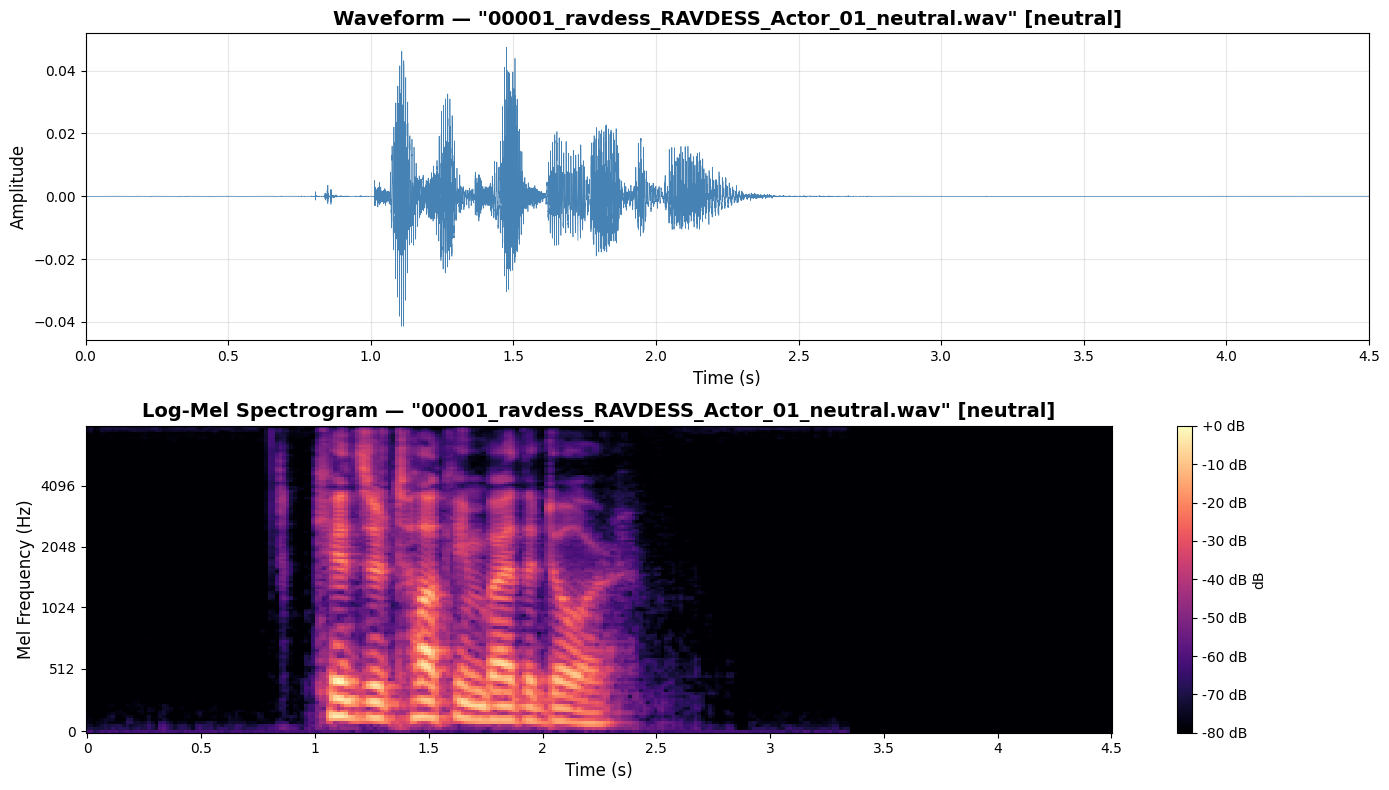


✅ Saved: mel_spectrogram_sample.png
   n_fft=1024 | hop_length=256 | n_mels=128 | sr=16000


In [7]:
# ====== VISUALIZE MEL SPECTROGRAM OF FIRST AUDIO FILE ======

import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

# Lấy file audio đầu tiên từ train set
first_row = df_train.iloc[0]
audio_path = first_row['audio_path']
emotion = first_row['emotion']
filename = first_row['filename']

print(f"File:    {filename}")
print(f"Path:    {audio_path}")
print(f"Emotion: {emotion}")

# Load audio
y, sr = librosa.load(audio_path, sr=SR, mono=True)
duration = len(y) / sr
print(f"Duration: {duration:.2f}s | Samples: {len(y)} | SR: {sr}")

# Compute mel spectrogram
mel = librosa.feature.melspectrogram(
    y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
    n_mels=N_MELS, power=2.0
)
log_mel = librosa.power_to_db(mel, ref=np.max)

print(f"Mel shape: {log_mel.shape}  (n_mels={log_mel.shape[0]}, time_frames={log_mel.shape[1]})")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- Waveform ---
ax1 = axes[0]
time_axis = np.arange(len(y)) / sr
ax1.plot(time_axis, y, color='steelblue', linewidth=0.5)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.set_title(f'Waveform — "{filename}" [{emotion}]', fontsize=14, fontweight='bold')
ax1.set_xlim([0, duration])
ax1.grid(True, alpha=0.3)

# --- Mel Spectrogram ---
ax2 = axes[1]
img = librosa.display.specshow(
    log_mel, sr=SR, hop_length=HOP_LENGTH,
    x_axis='time', y_axis='mel',
    ax=ax2, cmap='magma'
)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Mel Frequency (Hz)', fontsize=12)
ax2.set_title(f'Log-Mel Spectrogram — "{filename}" [{emotion}]', fontsize=14, fontweight='bold')
fig.colorbar(img, ax=ax2, format='%+2.0f dB', label='dB')

plt.tight_layout()
plt.savefig('/kaggle/working/mel_spectrogram_sample.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved: mel_spectrogram_sample.png")
print(f"   n_fft={N_FFT} | hop_length={HOP_LENGTH} | n_mels={N_MELS} | sr={SR}")

------------------------------------------------------------------------------------------------------------------

In [8]:
# ====== COMPUTE GLOBAL NORMALIZATION ======

print("Computing global normalization statistics...")

sum_vals = 0.0
sum_sq = 0.0
count = 0

for path in tqdm(train_feat_df['mel_path'], desc="Computing stats"):
    mel = np.load(path)
    sum_vals += mel.sum()
    sum_sq += (mel ** 2).sum()
    count += mel.size

GLOBAL_MEAN = sum_vals / count
GLOBAL_STD = np.sqrt((sum_sq / count) - (GLOBAL_MEAN ** 2))

print(f"GLOBAL_MEAN: {GLOBAL_MEAN:.6f}")
print(f"GLOBAL_STD:  {GLOBAL_STD:.6f}")

gc.collect()

Computing global normalization statistics...


Computing stats:   0%|          | 0/14236 [00:00<?, ?it/s]

GLOBAL_MEAN: -49.383110
GLOBAL_STD:  19.891521


19067

In [9]:
# ====== DATASET & DATALOADER ======

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")


class SERDataset(Dataset):
    def __init__(self, df, mean=None, std=None):
        self.df = df.reset_index(drop=True)
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        mel = np.load(self.df.iloc[idx]['mel_path'])  # (1, T, 128, 1)
        mel = torch.tensor(mel, dtype=torch.float32)

        if self.mean is not None and self.std is not None:
            mel = (mel - self.mean) / (self.std + 1e-6)

        label = torch.tensor(self.df.iloc[idx]['label_idx'], dtype=torch.long)
        return mel, label


def collate_fn_pad(batch):
    """Pad sequences to max length in batch"""
    mels = [item[0] for item in batch]
    labels = [item[1] for item in batch]

    max_T = max(mel.shape[1] for mel in mels)  # dim 1 = time

    padded = []
    for mel in mels:
        pad_width = max_T - mel.shape[1]
        # mel shape: (1, T, 128, 1) → pad along T (dim=1)
        # F.pad format: last dim first → (0,0, 0,0, 0,pad_width, 0,0)
        padded_mel = F.pad(mel, (0, 0, 0, 0, 0, pad_width, 0, 0), 'constant', 0)
        padded.append(padded_mel)

    return torch.stack(padded), torch.stack(labels)


BATCH_SIZE = 16

train_dataset = SERDataset(train_feat_df, mean=GLOBAL_MEAN, std=GLOBAL_STD)
val_dataset   = SERDataset(val_feat_df,   mean=GLOBAL_MEAN, std=GLOBAL_STD)
test_dataset  = SERDataset(test_feat_df,  mean=GLOBAL_MEAN, std=GLOBAL_STD)

num_workers = 2 if os.cpu_count() and os.cpu_count() > 2 else 0

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=num_workers, pin_memory=(device.type == 'cuda'),
    collate_fn=collate_fn_pad,
    persistent_workers=(num_workers > 0)
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers, pin_memory=(device.type == 'cuda'),
    collate_fn=collate_fn_pad,
    persistent_workers=(num_workers > 0)
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=(device.type == 'cuda'),
    collate_fn=collate_fn_pad
)

print(f"DataLoaders ready")
print(f"   Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}")

Device: cuda
   GPU: Tesla T4
DataLoaders ready
   Train: 890 batches | Val: 31 | Test: 31


In [10]:
# ====== MODEL ARCHITECTURE ======

class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim, dropout_rate=0.5):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        scores = self.attn(x)                    # (B, T, 1)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(weights * x, dim=1)  # (B, D)
        return context, weights


class SER3DCNN_BiLSTM_Attn(nn.Module):
    """
    3D CNN + BiLSTM + Temporal Attention for SER
    Input: (B, 1, T, 128, 1)
    """
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super().__init__()
        self.lstm_hidden = 192
        lstm_output_dim = self.lstm_hidden * 2

        # ---- Temporal CNN (Conv3D) ----
        self.cnn = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=(5, 3, 1), padding=(2, 1, 0)),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d((2, 2, 1)),

            nn.Conv3d(32, 64, kernel_size=(5, 3, 1), padding=(2, 1, 0)),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d((2, 2, 1)),

            nn.Conv3d(64, 128, kernel_size=(3, 3, 1), padding=(1, 1, 0)),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.MaxPool3d((1, 2, 1))
        )

        self.pool = nn.AdaptiveAvgPool3d((None, 1, 1))
        self.proj = nn.Linear(128, 256)

        # ---- BiLSTM ----
        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=self.lstm_hidden,
            num_layers=2,
            dropout=dropout_rate,
            bidirectional=True,
            batch_first=True
        )

        # ---- Attention ----
        self.attention = TemporalAttention(lstm_output_dim, dropout_rate)

        # ---- Classifier ----
        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_dim, self.lstm_hidden),
            nn.BatchNorm1d(self.lstm_hidden),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(self.lstm_hidden, num_classes)
        )

    def forward(self, x):
        """x: (B, 1, T, 128, 1)"""
        x = self.cnn(x)
        x = self.pool(x)              # (B, 128, T', 1, 1)

        B, C, T, _, _ = x.shape
        x = x.permute(0, 2, 1, 3, 4).contiguous()
        x = x.view(B, T, C)           # (B, T', 128)

        x = self.proj(x)              # (B, T', 256)
        lstm_out, _ = self.lstm(x)    # (B, T', 384)
        context, attn_w = self.attention(lstm_out)
        logits = self.classifier(context)
        probs = F.softmax(logits, dim=1)
        return probs


# ====== INIT MODEL ======
model = SER3DCNN_BiLSTM_Attn(num_classes=NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📐 Model: 3D CNN + BiLSTM + Attention")
print(f"   Total params:     {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")

# Sanity check
dummy = torch.randn(2, 1, 100, 128, 1).to(device)
out = model(dummy)
print(f"   Sanity check: input={dummy.shape} → output={out.shape}")
assert out.shape == (2, NUM_CLASSES), f"Expected (2, {NUM_CLASSES}), got {out.shape}"


📐 Model: 3D CNN + BiLSTM + Attention
   Total params:     1,867,400
   Trainable params: 1,867,400
   Sanity check: input=torch.Size([2, 1, 100, 128, 1]) → output=torch.Size([2, 7])


In [11]:
# %% [code]
# ====== MODEL SUMMARY ======

!pip install -q torchinfo
from torchinfo import summary

# Lấy T thực tế từ sample đầu tiên
T = np.load(train_feat_df.iloc[0]['mel_path']).shape[1]
print(f"T (time frames) = {T}")

summary(
    model,
    input_size=(BATCH_SIZE, 1, T, 128, 1),
    col_names=["input_size", "output_size", "num_params", "kernel_size"],
    col_width=18,
    row_settings=["var_names"],
    depth=4,
    device=device
)

T (time frames) = 282


Layer (type (var_name))                       Input Shape        Output Shape       Param #            Kernel Shape
SER3DCNN_BiLSTM_Attn (SER3DCNN_BiLSTM_Attn)   [16, 1, 282, 128, 1] [16, 7]            --                 --
├─Sequential (cnn)                            [16, 1, 282, 128, 1] [16, 128, 70, 16, 1] --                 --
│    └─Conv3d (0)                             [16, 1, 282, 128, 1] [16, 32, 282, 128, 1] 512                [5, 3, 1]
│    └─BatchNorm3d (1)                        [16, 32, 282, 128, 1] [16, 32, 282, 128, 1] 64                 --
│    └─ReLU (2)                               [16, 32, 282, 128, 1] [16, 32, 282, 128, 1] --                 --
│    └─MaxPool3d (3)                          [16, 32, 282, 128, 1] [16, 32, 141, 64, 1] --                 [2, 2, 1]
│    └─Conv3d (4)                             [16, 32, 141, 64, 1] [16, 64, 141, 64, 1] 30,784             [5, 3, 1]
│    └─BatchNorm3d (5)                        [16, 64, 141, 64, 1] [16, 64, 141, 64, 1] 1

In [12]:
# ====== LOSS, OPTIMIZER, SCHEDULER ======

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

print("Loss, Optimizer, Scheduler ready")

Loss, Optimizer, Scheduler ready


In [13]:
### ====== TRAINING LOOP ======

NUM_EPOCHS = 50
PATIENCE = 10
BEST_MODEL_PATH = '/kaggle/working/best_model.pt'

print("\n" + "=" * 70)
print("TRAINING START")
print("=" * 70)
print(f"   Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE} | Patience: {PATIENCE}")
print(f"   Train: {len(train_feat_df)} | Val: {len(val_feat_df)}")
print(f"   LR: {optimizer.param_groups[0]['lr']:.2e}")
print("=" * 70)

# WandB init
config = {
    "model": "3DCNN-BiLSTM-Attention",
    "lr": 1e-4,
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "num_classes": NUM_CLASSES,
    "dataset": "SAVEE+RAVDESS+TESS",
    "features": "log-mel-128",
}
run = wandb.init(
    project="SER-3DCNN-BiLSTM-ATT",
    config=config,
    name=f"SER_3DCNN_{time.strftime('%m%d_%H%M')}",
)

best_val_acc = 0.0
patience_counter = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # ==================== TRAIN ====================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS} [Train]",
                leave=False, ncols=100)

    for batch_idx, (mel, label) in enumerate(pbar):
        mel, label = mel.to(device), label.to(device)

        optimizer.zero_grad()
        logits = model(mel)
        loss = criterion(logits, label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(epoch + batch_idx / len(train_loader))

        train_loss += loss.item()
        preds = logits.argmax(dim=1)
        train_correct += (preds == label).sum().item()
        train_total += label.size(0)

        pbar.set_postfix(
            loss=f"{loss.item():.3f}",
            acc=f"{train_correct/train_total:.3f}"
        )

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    # ==================== VALIDATION ====================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for mel, label in tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS} [Val  ]",
                               leave=False, ncols=100):
            mel, label = mel.to(device), label.to(device)
            logits = model(mel)
            loss = criterion(logits, label)

            val_loss += loss.item()
            val_correct += (logits.argmax(1) == label).sum().item()
            val_total += label.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    epoch_time = time.time() - epoch_start

    # ==================== LOGGING ====================
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    lr_now = optimizer.param_groups[0]['lr']

    # Determine status icon
    improved = val_acc > best_val_acc + 0.003
    if improved:
        status = "NEW BEST"
    elif patience_counter >= PATIENCE - 3:
        status = "DANGER"
    else:
        status = ""

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} │ "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} │ "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} │ "
        f"LR: {lr_now:.2e} │ "
        f"{epoch_time:.0f}s │ {status}"
    )

    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/acc": train_acc,
        "val/loss": val_loss,
        "val/acc": val_acc,
        "lr": lr_now,
    })

    # ==================== EARLY STOPPING ====================
    if improved:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"         Model saved! Best Val Acc: {best_val_acc:.4f}")
    else:
        patience_counter += 1
        print(f"         No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}!")
            break

    # Memory cleanup
    if (epoch + 1) % 5 == 0:
        gc.collect()
        if device.type == 'cuda':
            torch.cuda.empty_cache()

print("\n" + "=" * 70)
print(f"TRAINING COMPLETE | Best Val Acc: {best_val_acc:.4f}")
print("=" * 70)


TRAINING START
   Epochs: 50 | Batch: 16 | Patience: 10
   Train: 14236 | Val: 484
   LR: 1.00e-04


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260313_034609-ck63nen2
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run SER_3DCNN_0313_0346
wandb: ⭐️ View project at https://wandb.ai/minhtrietsonny-fpt-university/SER-3DCNN-BiLSTM-ATT
wandb: 🚀 View run at https://wandb.ai/minhtrietsonny-fpt-university/SER-3DCNN-BiLSTM-ATT/runs/ck63nen2


Epoch 01/50 [Train]:   0%|                                                  | 0/890 [00:00<?, ?it/s]

Epoch 01/50 [Val  ]:   0%|                                                   | 0/31 [00:00<?, ?it/s]

Epoch 01/50 │ Train Loss: 1.6935  Acc: 0.5449 │ Val Loss: 1.5906  Acc: 0.6260 │ LR: 9.76e-05 │ 220s │ NEW BEST
         Model saved! Best Val Acc: 0.6260


...

Epoch 35/50 [Val  ]:   0%|                                                   | 0/31 [00:00<?, ?it/s]

Epoch 35/50 │ Train Loss: 1.3440  Acc: 0.8963 │ Val Loss: 1.3934  Acc: 0.8450 │ LR: 9.62e-05 │ 221s │ DANGER
         No improvement (9/10)


Epoch 36/50 [Train]:   0%|                                                  | 0/890 [00:00<?, ?it/s]

Epoch 36/50 [Val  ]:   0%|                                                   | 0/31 [00:00<?, ?it/s]

Epoch 36/50 │ Train Loss: 1.3380  Acc: 0.9031 │ Val Loss: 1.4033  Acc: 0.8347 │ LR: 9.46e-05 │ 221s │ DANGER
         No improvement (10/10)

Early stopping at epoch 36!

TRAINING COMPLETE | Best Val Acc: 0.8740


In [14]:
# ====== EVALUATION ON TEST SET ======

print("\n" + "=" * 70)
print("EVALUATION ON COMBINED TEST SET")
print("=" * 70)

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()
print(f"Loaded best model (Val Acc: {best_val_acc:.4f})")

all_preds = []
all_labels = []

with torch.no_grad():
    for mel, label in tqdm(test_loader, desc="Testing"):
        mel = mel.to(device)
        logits = model(mel)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(label.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"\nTEST ACCURACY: {test_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=EMOTION_LABELS))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

wandb.log({"test/accuracy": test_acc})


EVALUATION ON COMBINED TEST SET
Loaded best model (Val Acc: 0.8740)


Testing:   0%|          | 0/31 [00:00<?, ?it/s]


TEST ACCURACY: 0.8636

Classification Report:
              precision    recall  f1-score   support

     neutral       0.76      0.98      0.86        52
       happy       0.86      0.79      0.83        72
         sad       0.87      0.83      0.85        72
       angry       0.93      0.89      0.91        72
        fear       0.89      0.86      0.87        72
     disgust       0.86      0.85      0.85        72
    surprise       0.88      0.88      0.88        72

    accuracy                           0.86       484
   macro avg       0.86      0.87      0.86       484
weighted avg       0.87      0.86      0.86       484

Confusion Matrix:
[[51  0  0  1  0  0  0]
 [ 4 57  1  4  1  1  4]
 [ 7  2 60  0  1  1  1]
 [ 0  2  1 64  2  3  0]
 [ 2  2  2  0 62  2  2]
 [ 3  1  4  0  1 61  2]
 [ 0  2  1  0  3  3 63]]


In [15]:
# ====== EVALUATION ON INDIVIDUAL DATASETS ======

print("\n" + "=" * 70)
print("EVALUATION ON INDIVIDUAL DATASETS (RAVDESS / SAVEE / TESS)")
print("=" * 70)


def evaluate_individual_dataset(csv_path, audio_dir, dataset_name):
    """Extract features, build loader, and evaluate on a single dataset"""
    if not os.path.exists(csv_path):
        print(f"[{dataset_name}] CSV not found: {csv_path}")
        return

    df = pd.read_csv(csv_path)
    df = prepare_df(df, audio_dir, dataset_name)

    if len(df) == 0:
        print(f"[{dataset_name}] No valid samples after preparation")
        return

    # Extract features
    feat_df = extract_and_save_features(df, f'test_{dataset_name.lower()}')

    if len(feat_df) == 0:
        print(f"[{dataset_name}] No features extracted")
        return

    # Build dataset & loader
    ds = SERDataset(feat_df, mean=GLOBAL_MEAN, std=GLOBAL_STD)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, collate_fn=collate_fn_pad,
                        pin_memory=(device.type == 'cuda'))

    # Evaluate
    preds_list = []
    labels_list = []

    model.eval()
    with torch.no_grad():
        for mel, label in tqdm(loader, desc=f"Testing [{dataset_name}]"):
            mel = mel.to(device)
            logits = model(mel)
            preds_list.extend(logits.argmax(1).cpu().numpy())
            labels_list.extend(label.numpy())

    preds_arr = np.array(preds_list)
    labels_arr = np.array(labels_list)

    acc = (preds_arr == labels_arr).mean()
    print(f"\n[{dataset_name}] Accuracy: {acc:.4f} ({len(labels_arr)} samples)")

    # Only show labels that exist in this dataset
    present_labels = sorted(set(labels_arr))
    present_names = [EMOTION_LABELS[i] for i in present_labels]
    print(classification_report(labels_arr, preds_arr,
                                labels=present_labels,
                                target_names=present_names))

    wandb.log({f"test/{dataset_name.lower()}_accuracy": acc})
    return acc


ravdess_acc = evaluate_individual_dataset(RAVDESS_TEST_CSV, RAVDESS_TEST_DIR, "RAVDESS")
savee_acc   = evaluate_individual_dataset(SAVEE_TEST_CSV,   SAVEE_TEST_DIR,   "SAVEE")
tess_acc    = evaluate_individual_dataset(TESS_TEST_CSV,    TESS_TEST_DIR,    "TESS")

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"   Combined Test Acc:  {test_acc:.4f}")
if ravdess_acc is not None: print(f"   RAVDESS Test Acc:   {ravdess_acc:.4f}")
if savee_acc is not None:   print(f"   SAVEE Test Acc:     {savee_acc:.4f}")
if tess_acc is not None:    print(f"   TESS Test Acc:      {tess_acc:.4f}")
print("=" * 70)


EVALUATION ON INDIVIDUAL DATASETS (RAVDESS / SAVEE / TESS)
 [RAVDESS] Files found: 144/144


Extracting [test_ravdess]:   0%|          | 0/144 [00:00<?, ?it/s]

    Sample shape: raw=(128, 282), saved=(1, 282, 128, 1)
   Done: 144 OK, 0 errors, 1.2s (119 files/s)


Testing [RAVDESS]:   0%|          | 0/9 [00:00<?, ?it/s]


[RAVDESS] Accuracy: 0.7083 (144 samples)
              precision    recall  f1-score   support

       happy       0.69      0.46      0.55        24
         sad       0.67      0.67      0.67        24
       angry       0.83      0.79      0.81        24
        fear       0.76      0.79      0.78        24
     disgust       0.74      0.71      0.72        24
    surprise       0.87      0.83      0.85        24

   micro avg       0.76      0.71      0.73       144
   macro avg       0.76      0.71      0.73       144
weighted avg       0.76      0.71      0.73       144

 [SAVEE] Files found: 60/60


...


[SAVEE] Accuracy: 0.6000 (60 samples)
              precision    recall  f1-score   support

     neutral       0.65      0.92      0.76        12
       happy       0.60      0.75      0.67         8
         sad       0.80      0.50      0.62         8
       angry       0.83      0.62      0.71         8
        fear       0.60      0.38      0.46         8
     disgust       0.50      0.50      0.50         8
    surprise       0.33      0.38      0.35         8

    accuracy                           0.60        60
   macro avg       0.62      0.58      0.58        60
weighted avg       0.62      0.60      0.59        60

 [TESS] Files found: 280/280


Extracting [test_tess]:   0%|          | 0/280 [00:00<?, ?it/s]

    Sample shape: raw=(128, 282), saved=(1, 282, 128, 1)
   Done: 280 OK, 0 errors, 2.4s (116 files/s)


Testing [TESS]:   0%|          | 0/18 [00:00<?, ?it/s]


[TESS] Accuracy: 1.0000 (280 samples)
              precision    recall  f1-score   support

     neutral       1.00      1.00      1.00        40
       happy       1.00      1.00      1.00        40
         sad       1.00      1.00      1.00        40
       angry       1.00      1.00      1.00        40
        fear       1.00      1.00      1.00        40
     disgust       1.00      1.00      1.00        40
    surprise       1.00      1.00      1.00        40

    accuracy                           1.00       280
   macro avg       1.00      1.00      1.00       280
weighted avg       1.00      1.00      1.00       280


SUMMARY
   Combined Test Acc:  0.8636
   RAVDESS Test Acc:   0.7083
   SAVEE Test Acc:     0.6000
   TESS Test Acc:      1.0000


In [16]:
# ====== SAVE FINAL MODEL ======

final_model_path = '/kaggle/working/ser_3dcnn_bilstm_attn_final.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes': NUM_CLASSES,
    'label_mapping': label_mapping,
    'sample_rate': SR,
    'n_mels': N_MELS,
    'n_fft': N_FFT,
    'hop_length': HOP_LENGTH,
    'global_mean': GLOBAL_MEAN,
    'global_std': GLOBAL_STD,
    'architecture': '3DCNN-BiLSTM-Attention',
    'datasets': ['RAVDESS', 'SAVEE', 'TESS'],
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
}, final_model_path)

print(f"Final model saved to {final_model_path}")

wandb.finish()
print("WandB run finished")

wandb: updating run metadata


Final model saved to /kaggle/working/ser_3dcnn_bilstm_attn_final.pth


wandb: 
wandb: Run history:
wandb:                 epoch ▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
wandb:                    lr █▇▇▆▅▃▂▂▁▁███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁██████
wandb:         test/accuracy ▁
wandb: test/ravdess_accuracy ▁
wandb:   test/savee_accuracy ▁
wandb:    test/tess_accuracy ▁
wandb:             train/acc ▁▄▅▅▆▆▆▆▆▇▆▆▆▆▆▇▇▇▇▇▇▇████████▇▇▇▇▇▇
wandb:            train/loss █▅▄▃▃▃▃▃▂▂▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▂▂▂▂▂▁
wandb:               val/acc ▁▄▅▄▆▆▆▆▇▆▆▆▆▆▇▇▆▇▇▇▇▇▇█▇█████▆▇▇▆▇▇
wandb:              val/loss █▅▄▅▃▃▃▃▂▃▃▃▃▃▃▂▃▂▂▂▁▂▂▁▂▁▁▁▁▁▃▂▂▃▂▂
wandb: 
wandb: Run summary:
wandb:                 epoch 36
wandb:                    lr 9e-05
wandb:         test/accuracy 0.86364
wandb: test/ravdess_accuracy 0.70833
wandb:   test/savee_accuracy 0.6
wandb:    test/tess_accuracy 1
wandb:             train/acc 0.90313
wandb:            train/loss 1.338
wandb:               val/acc 0.83471
wandb:              val/loss 1.40334
wandb: 
wandb: 🚀 View run SER_3DCNN_0313_0346 at: https://wandb.ai/minhtr

WandB run finished


# LEARNING CURVE

# 📊 VISUALIZATION: ROC, AUC, Confusion Matrix, Learning Curves

In [17]:
# ====== IMPORTS FOR VISUALIZATION ======
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
import numpy as np

print("=" * 70)
print("VISUALIZATION & METRICS")
print("=" * 70)

VISUALIZATION & METRICS


In [18]:
# ====== 1. GET PREDICTIONS WITH PROBABILITIES ======
print("Getting predictions with probabilities from test set...")

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for mel, label in tqdm(test_loader, desc="Getting probabilities"):
        mel = mel.to(device)
        probs = model(mel)
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(probs.argmax(1).cpu().numpy())
        all_labels.extend(label.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()

print(f"   Samples:    {len(all_labels)}")
print(f"   Probs shape: {all_probs.shape}")
print(f"   Test Acc:    {test_acc:.4f}")

Getting predictions with probabilities from test set...


Getting probabilities:   0%|          | 0/31 [00:00<?, ?it/s]

   Samples:    484
   Probs shape: (484, 7)
   Test Acc:    0.8636


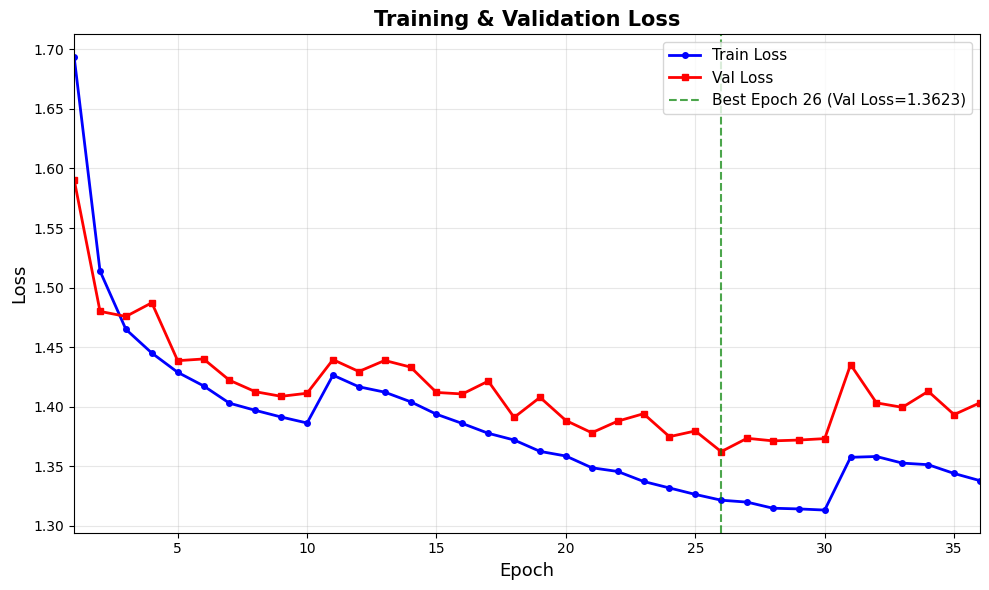

✅ Saved: train_val_loss.png


In [19]:
# ====== 2. TRAIN/VAL LOSS ======

fig, ax = plt.subplots(figsize=(10, 6))

epochs_range = range(1, len(history['train_loss']) + 1)

ax.plot(epochs_range, history['train_loss'], 'b-o',
        label='Train Loss', linewidth=2, markersize=4)
ax.plot(epochs_range, history['val_loss'], 'r-s',
        label='Val Loss', linewidth=2, markersize=4)

# Mark best epoch (lowest val loss)
best_loss_epoch = np.argmin(history['val_loss']) + 1
best_loss_val = min(history['val_loss'])
ax.axvline(x=best_loss_epoch, color='green', linestyle='--', alpha=0.7,
           label=f'Best Epoch {best_loss_epoch} (Val Loss={best_loss_val:.4f})')

ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Loss', fontsize=13)
ax.set_title('Training & Validation Loss', fontsize=15, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([1, len(history['train_loss'])])

plt.tight_layout()
plt.savefig('/kaggle/working/train_val_loss.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: train_val_loss.png")

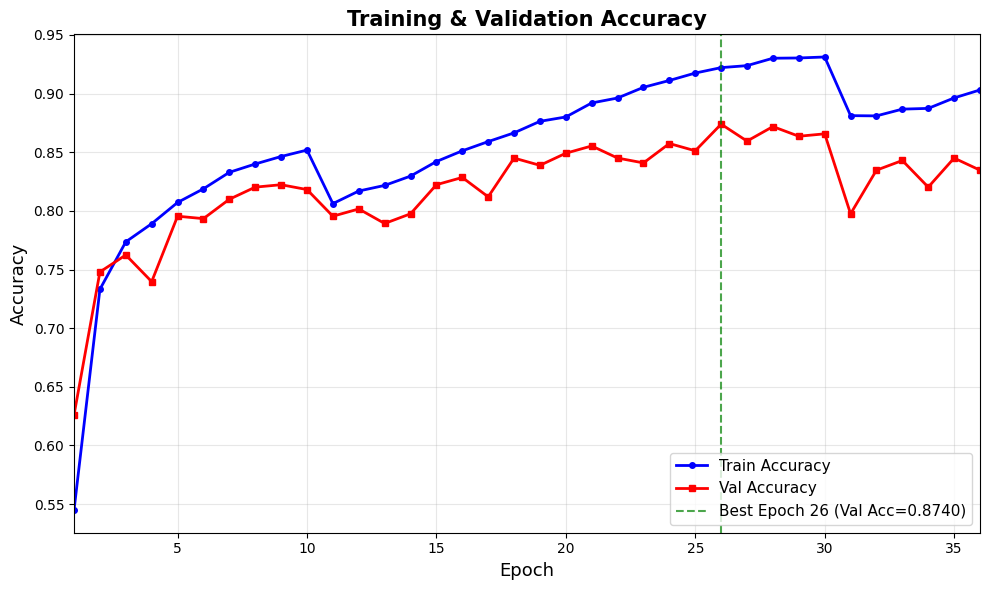

✅ Saved: train_val_accuracy.png


In [20]:
# ====== 3. TRAIN/VAL ACCURACY ======

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epochs_range, history['train_acc'], 'b-o',
        label='Train Accuracy', linewidth=2, markersize=4)
ax.plot(epochs_range, history['val_acc'], 'r-s',
        label='Val Accuracy', linewidth=2, markersize=4)

# Mark best epoch (highest val acc)
best_acc_epoch = np.argmax(history['val_acc']) + 1
best_acc_val = max(history['val_acc'])
ax.axvline(x=best_acc_epoch, color='green', linestyle='--', alpha=0.7,
           label=f'Best Epoch {best_acc_epoch} (Val Acc={best_acc_val:.4f})')

ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Training & Validation Accuracy', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([1, len(history['train_acc'])])

plt.tight_layout()
plt.savefig('/kaggle/working/train_val_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: train_val_accuracy.png")

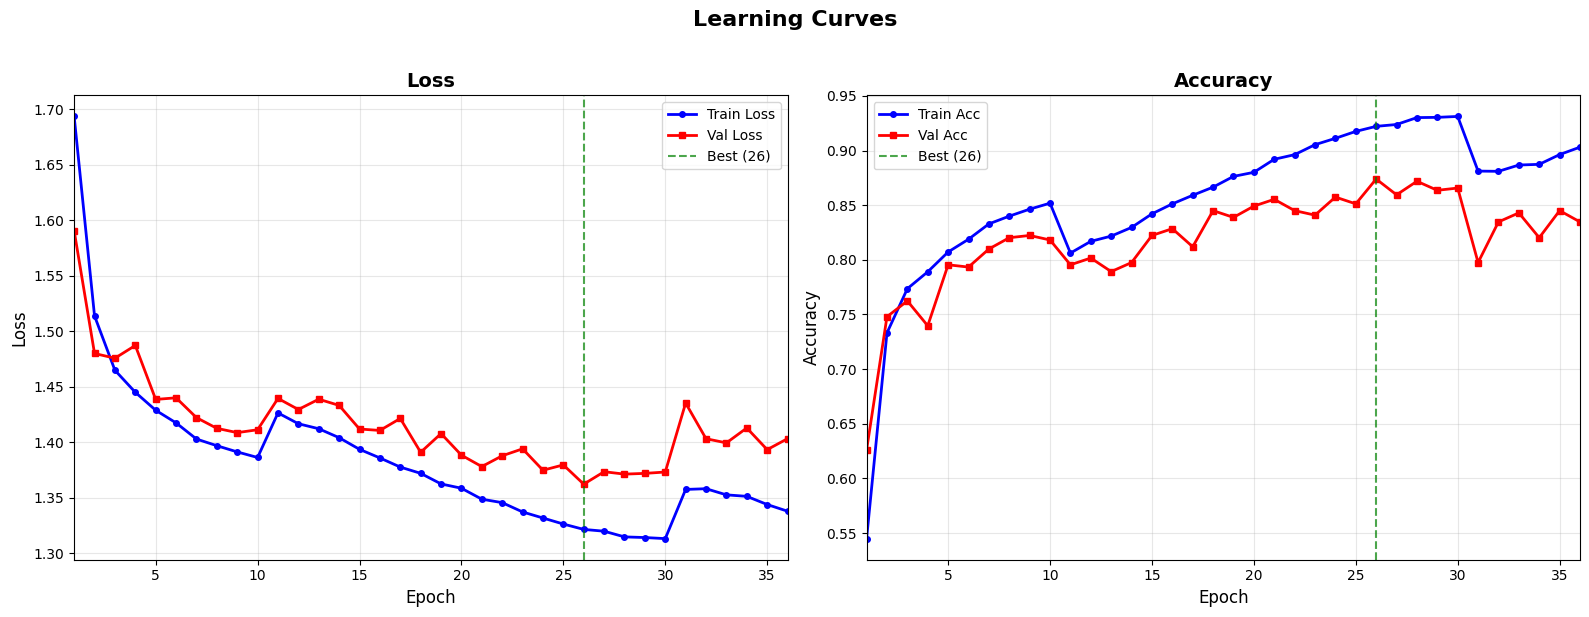

✅ Saved: learning_curves.png


In [21]:
# ====== 4. LEARNING CURVES (Loss + Accuracy Combined) ======

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss
ax1 = axes[0]
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
ax1.plot(epochs_range, history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
ax1.axvline(x=best_loss_epoch, color='green', linestyle='--', alpha=0.7,
            label=f'Best ({best_loss_epoch})')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([1, len(history['train_loss'])])

# Accuracy
ax2 = axes[1]
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', linewidth=2, markersize=4)
ax2.plot(epochs_range, history['val_acc'], 'r-s', label='Val Acc', linewidth=2, markersize=4)
ax2.axvline(x=best_acc_epoch, color='green', linestyle='--', alpha=0.7,
            label=f'Best ({best_acc_epoch})')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([1, len(history['train_acc'])])

fig.suptitle('Learning Curves', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: learning_curves.png")

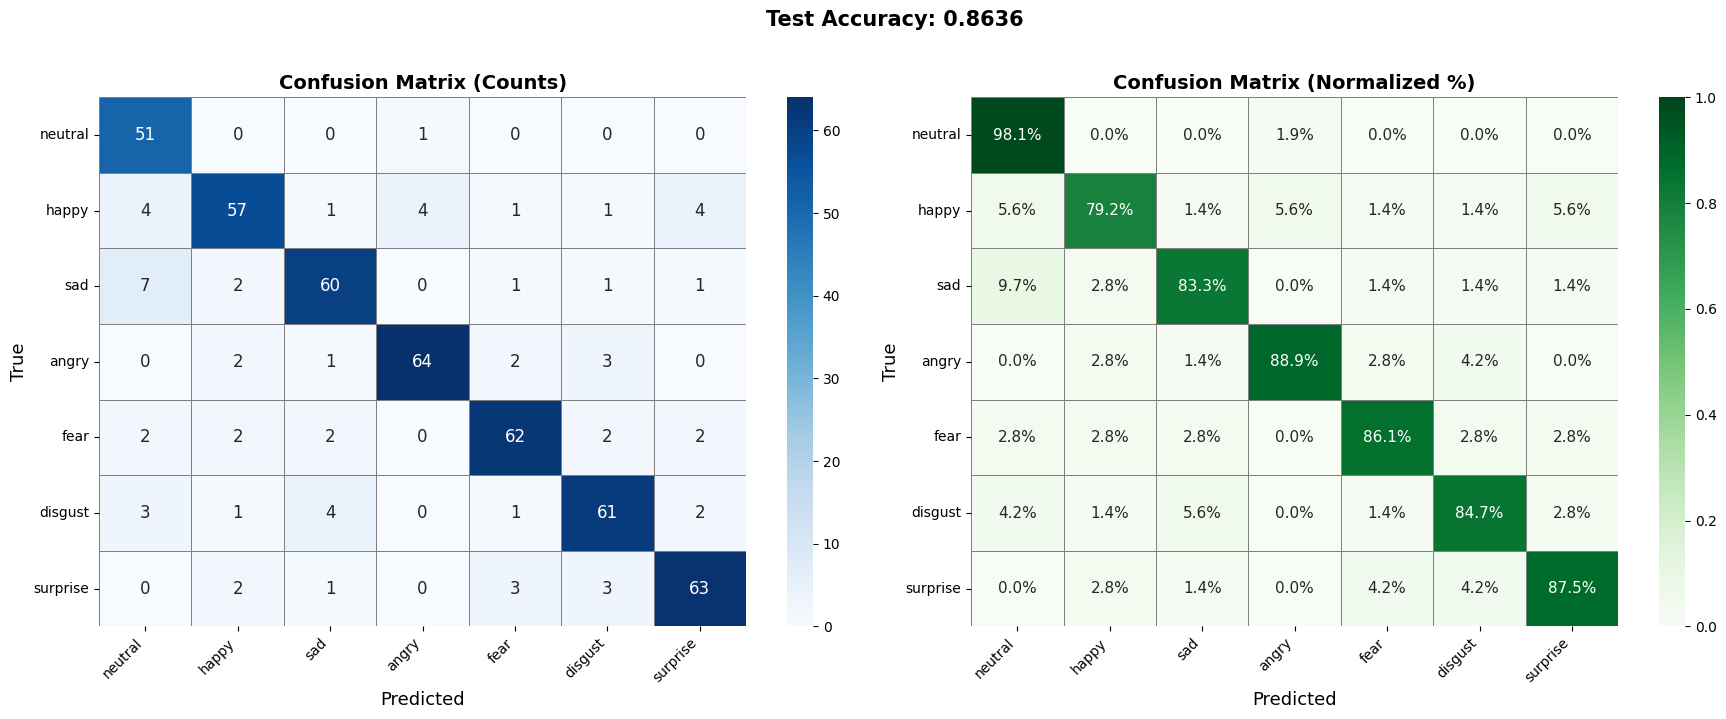

✅ Saved: confusion_matrix.png


In [22]:
# ====== 5. CONFUSION MATRIX ======

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
            annot_kws={'size': 12}, linewidths=0.5, linecolor='gray')
ax1.set_xlabel('Predicted', fontsize=13)
ax1.set_ylabel('True', fontsize=13)
ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)
plt.setp(ax1.get_yticklabels(), rotation=0, fontsize=10)

# Normalized
ax2 = axes[1]
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Greens', ax=ax2,
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
            annot_kws={'size': 11}, linewidths=0.5, linecolor='gray',
            vmin=0, vmax=1)
ax2.set_xlabel('Predicted', fontsize=13)
ax2.set_ylabel('True', fontsize=13)
ax2.set_title('Confusion Matrix (Normalized %)', fontsize=14, fontweight='bold')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=10)
plt.setp(ax2.get_yticklabels(), rotation=0, fontsize=10)

fig.suptitle(f'Test Accuracy: {test_acc:.4f}', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrix.png")

In [23]:
# ====== 6. ROC CURVES & AUC COMPUTATION ======

# Binarize labels
y_true_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
y_score = all_probs

# Per-class ROC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= NUM_CLASSES
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Print AUC
print("\n" + "=" * 50)
print("AUC SCORES")
print("=" * 50)
for i, emotion in enumerate(EMOTION_LABELS):
    print(f"   {emotion:<12s}: {roc_auc[i]:.4f}")
print("-" * 50)
print(f"   Micro-avg    : {roc_auc['micro']:.4f}")
print(f"   Macro-avg    : {roc_auc['macro']:.4f}")
print("=" * 50)


AUC SCORES
   neutral     : 0.9782
   happy       : 0.9744
   sad         : 0.9577
   angry       : 0.9705
   fear        : 0.9501
   disgust     : 0.9778
   surprise    : 0.9867
--------------------------------------------------
   Micro-avg    : 0.9696
   Macro-avg    : 0.9721


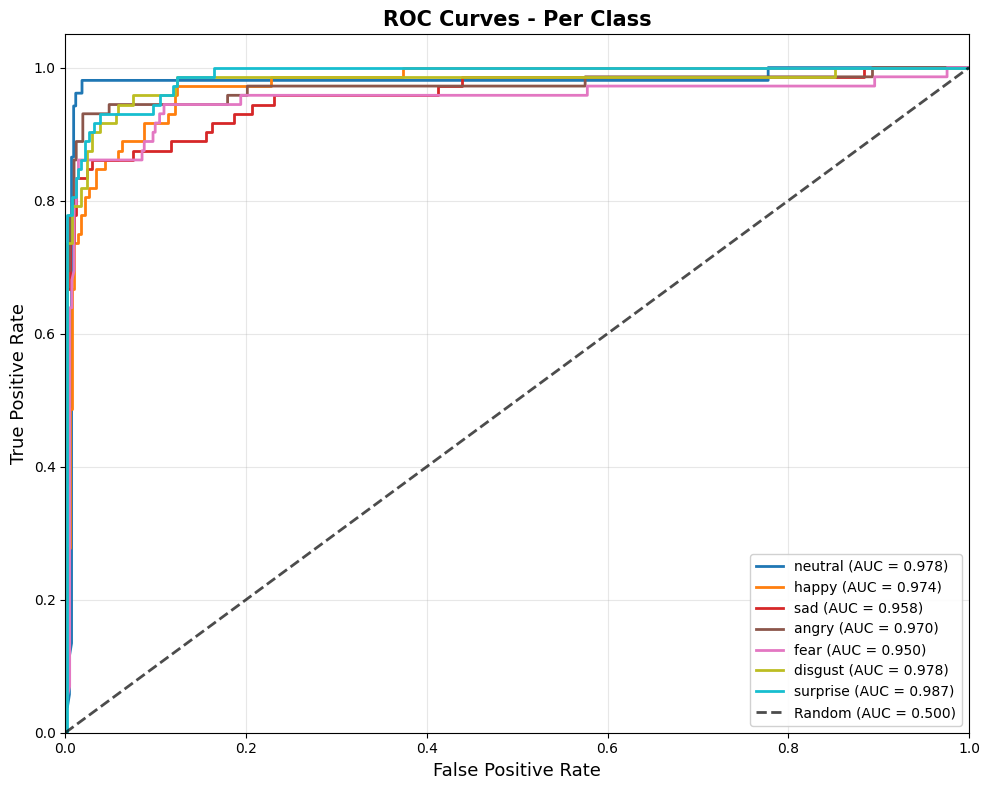

✅ Saved: roc_curve_all_classes.png


In [24]:
# ====== 7. ROC CURVE - ALL CLASSES ======

colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

fig, ax = plt.subplots(figsize=(10, 8))

for i, (color, emotion) in enumerate(zip(colors, EMOTION_LABELS)):
    ax.plot(fpr[i], tpr[i], color=color, lw=2,
            label=f'{emotion} (AUC = {roc_auc[i]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.7, label='Random (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves - Per Class', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve_all_classes.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: roc_curve_all_classes.png")

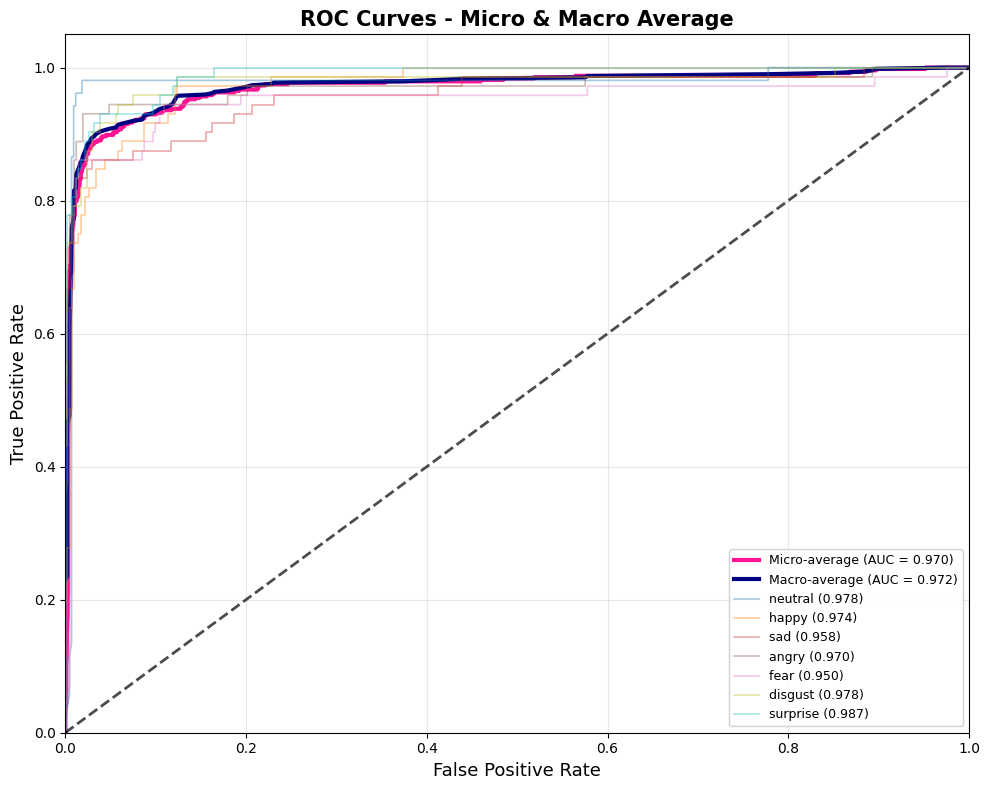

✅ Saved: roc_curve_avg.png


In [25]:
# ====== 8. ROC CURVE - MICRO & MACRO AVERAGE ======

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle='-', lw=3,
        label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')
ax.plot(fpr["macro"], tpr["macro"], color='navy', linestyle='-', lw=3,
        label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})')

# Individual classes (lighter)
for i, (color, emotion) in enumerate(zip(colors, EMOTION_LABELS)):
    ax.plot(fpr[i], tpr[i], color=color, lw=1.2, alpha=0.4,
            label=f'{emotion} ({roc_auc[i]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.7)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves - Micro & Macro Average', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve_avg.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: roc_curve_avg.png")

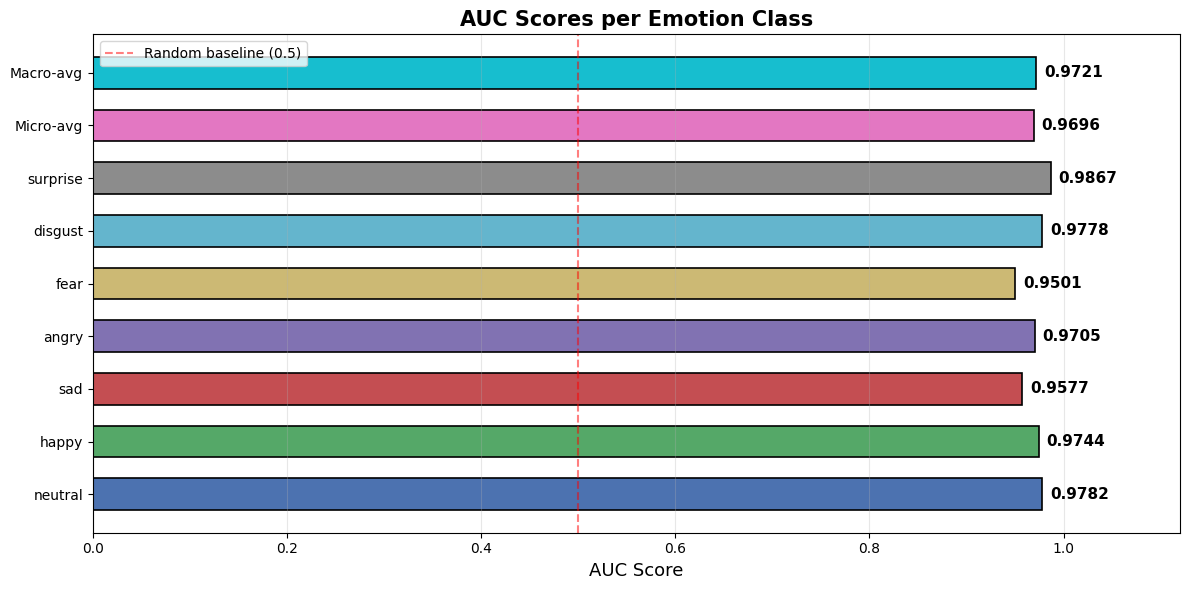

✅ Saved: auc_bar_chart.png


In [26]:
# ====== 9. AUC BAR CHART ======

fig, ax = plt.subplots(figsize=(12, 6))

bar_labels = EMOTION_LABELS + ['Micro-avg', 'Macro-avg']
bar_values = [roc_auc[i] for i in range(NUM_CLASSES)] + [roc_auc['micro'], roc_auc['macro']]
bar_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2',
              '#CCB974', '#64B5CD', '#8C8C8C', '#E377C2', '#17BECF']

bars = ax.barh(bar_labels, bar_values,
               color=bar_colors[:len(bar_labels)],
               edgecolor='black', linewidth=1.2, height=0.6)

# Value labels
for bar, val in zip(bars, bar_values):
    ax.text(val + 0.008, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=11, fontweight='bold')

ax.set_xlim([0, 1.12])
ax.set_xlabel('AUC Score', fontsize=13)
ax.set_title('AUC Scores per Emotion Class', fontsize=15, fontweight='bold')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline (0.5)')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/auc_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: auc_bar_chart.png")

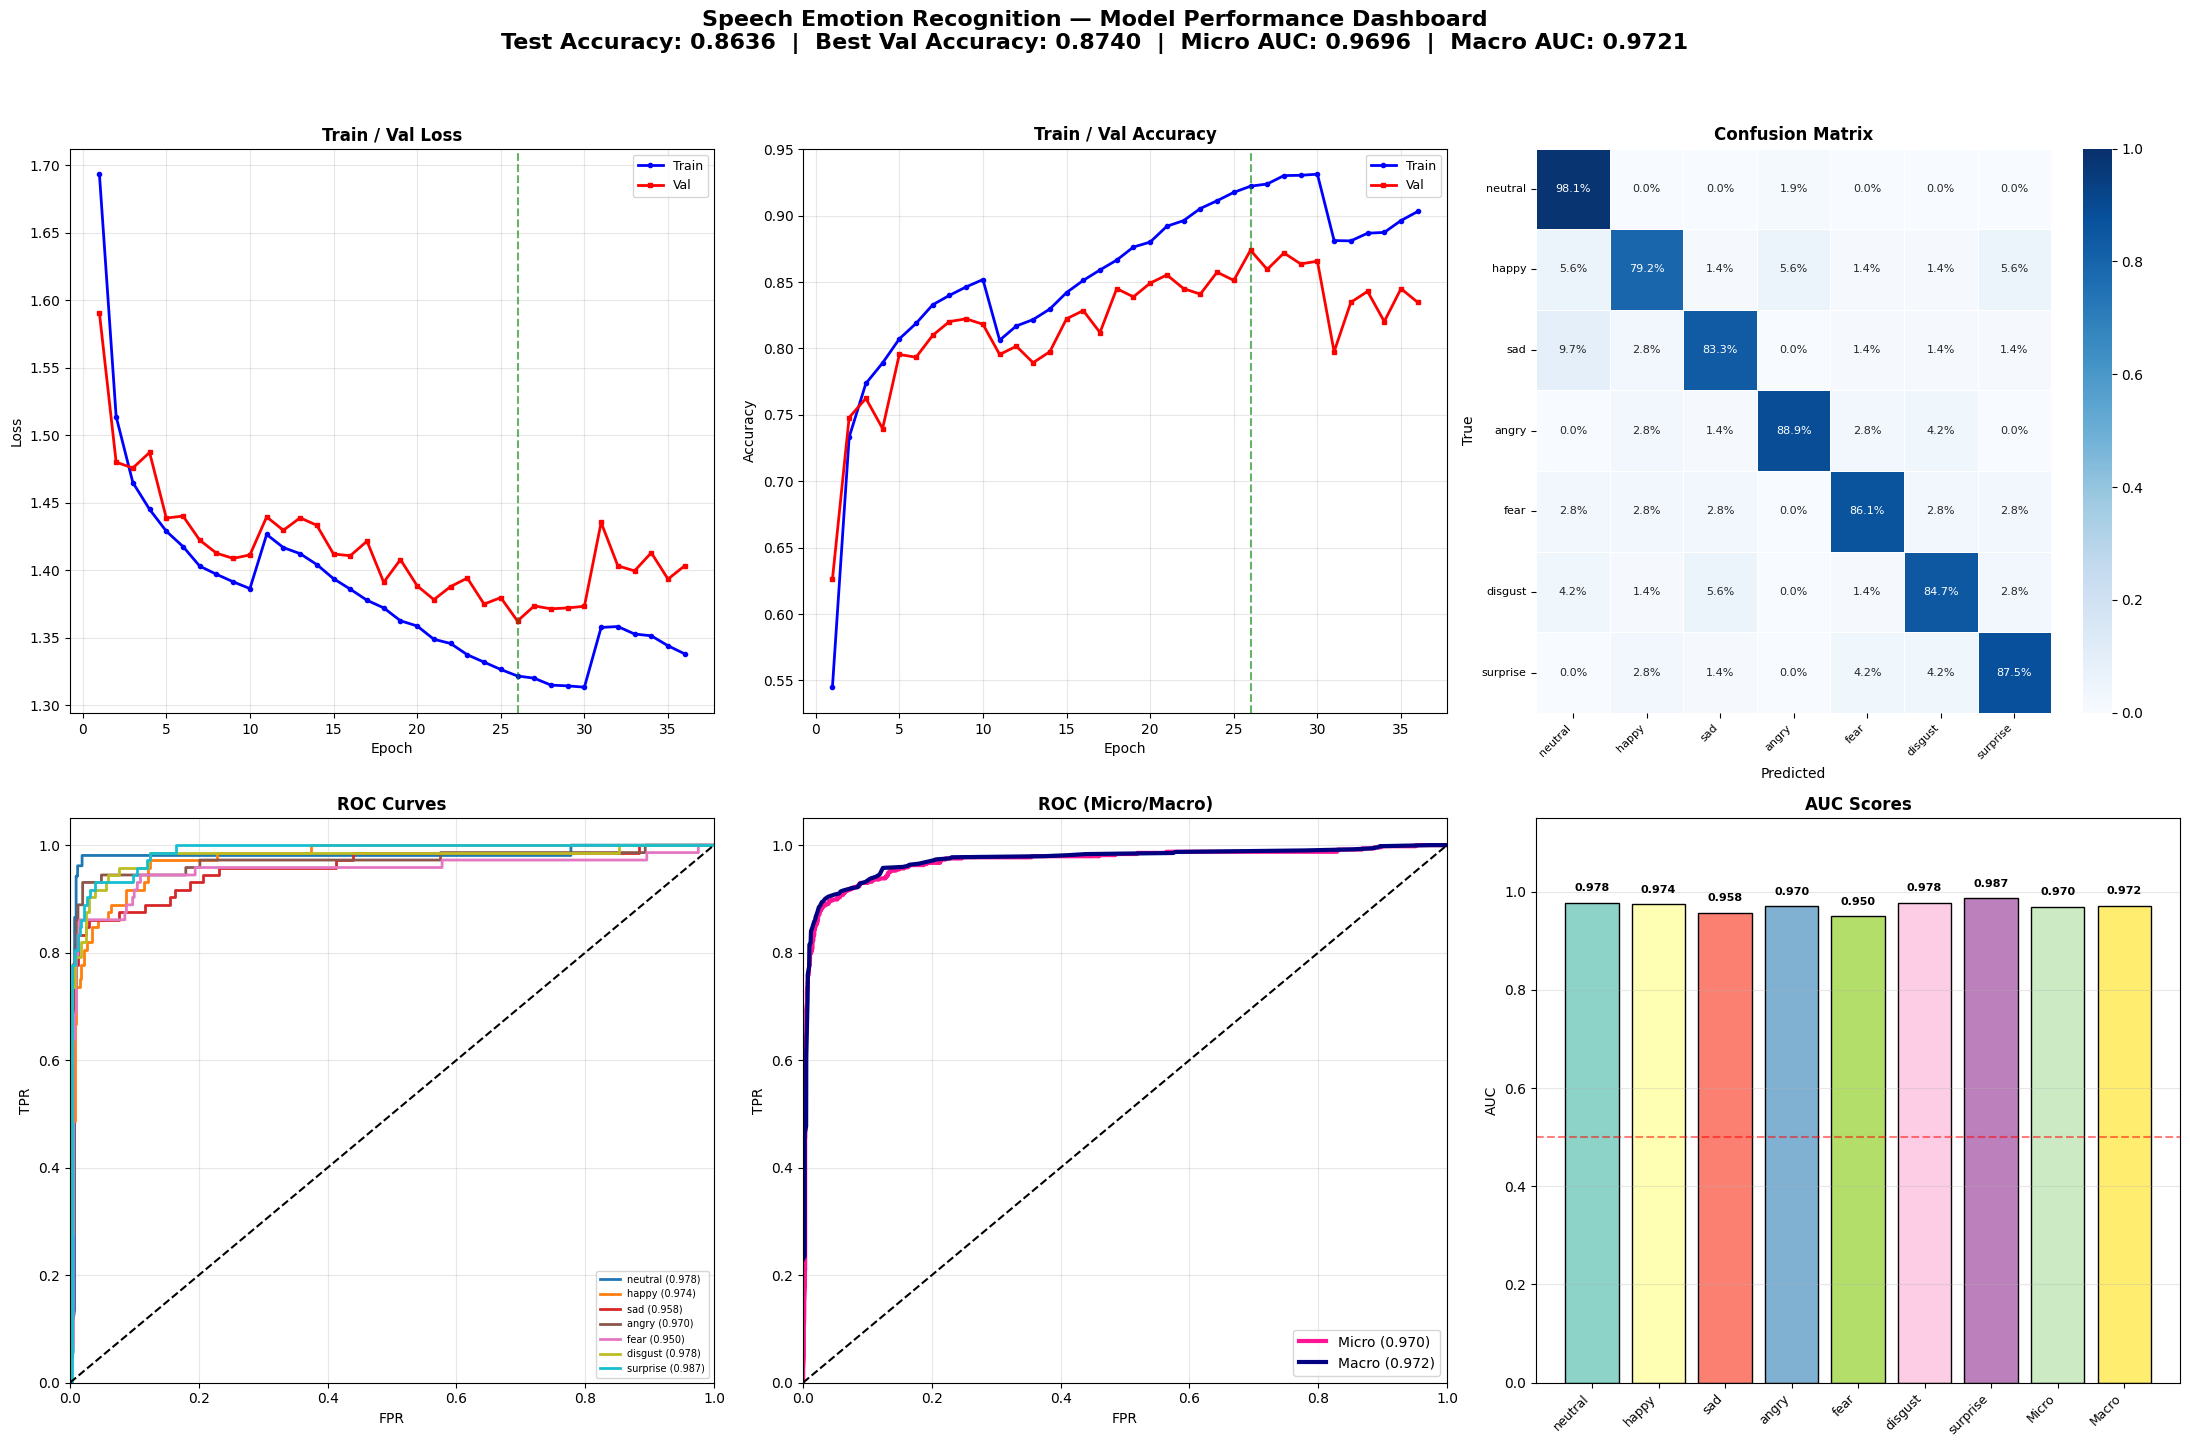

✅ Saved: summary_dashboard.png


In [27]:
# ====== 10. SUMMARY DASHBOARD (All-in-One) ======

fig = plt.figure(figsize=(22, 14))

# ---- Row 1, Col 1: Train/Val Loss ----
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train', lw=2, ms=3)
ax1.plot(epochs_range, history['val_loss'], 'r-s', label='Val', lw=2, ms=3)
ax1.axvline(x=best_loss_epoch, color='green', ls='--', alpha=0.6)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Train / Val Loss', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ---- Row 1, Col 2: Train/Val Accuracy ----
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train', lw=2, ms=3)
ax2.plot(epochs_range, history['val_acc'], 'r-s', label='Val', lw=2, ms=3)
ax2.axvline(x=best_acc_epoch, color='green', ls='--', alpha=0.6)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Train / Val Accuracy', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ---- Row 1, Col 3: Confusion Matrix (Normalized) ----
ax3 = fig.add_subplot(2, 3, 3)
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Blues', ax=ax3,
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
            annot_kws={'size': 8}, linewidths=0.5, vmin=0, vmax=1)
ax3.set_xlabel('Predicted', fontsize=10)
ax3.set_ylabel('True', fontsize=10)
ax3.set_title('Confusion Matrix', fontweight='bold')
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax3.get_yticklabels(), rotation=0, fontsize=8)

# ---- Row 2, Col 1: ROC Curves (All Classes) ----
ax4 = fig.add_subplot(2, 3, 4)
for i, (color, emotion) in enumerate(zip(colors, EMOTION_LABELS)):
    ax4.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{emotion} ({roc_auc[i]:.3f})')
ax4.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax4.set_xlim([0, 1])
ax4.set_ylim([0, 1.05])
ax4.set_xlabel('FPR')
ax4.set_ylabel('TPR')
ax4.set_title('ROC Curves', fontweight='bold')
ax4.legend(loc='lower right', fontsize=7)
ax4.grid(True, alpha=0.3)

# ---- Row 2, Col 2: ROC Micro/Macro ----
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(fpr["micro"], tpr["micro"], 'deeppink', lw=3,
         label=f'Micro ({roc_auc["micro"]:.3f})')
ax5.plot(fpr["macro"], tpr["macro"], 'navy', lw=3,
         label=f'Macro ({roc_auc["macro"]:.3f})')
ax5.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax5.set_xlim([0, 1])
ax5.set_ylim([0, 1.05])
ax5.set_xlabel('FPR')
ax5.set_ylabel('TPR')
ax5.set_title('ROC (Micro/Macro)', fontweight='bold')
ax5.legend(loc='lower right', fontsize=10)
ax5.grid(True, alpha=0.3)

# ---- Row 2, Col 3: AUC Bar Chart ----
ax6 = fig.add_subplot(2, 3, 6)
bar_names = EMOTION_LABELS + ['Micro', 'Macro']
bar_vals = [roc_auc[i] for i in range(NUM_CLASSES)] + [roc_auc['micro'], roc_auc['macro']]
bar_c = plt.cm.Set3(np.linspace(0, 1, len(bar_names)))
bars = ax6.bar(bar_names, bar_vals, color=bar_c, edgecolor='black')
ax6.set_ylim([0, 1.15])
ax6.set_ylabel('AUC')
ax6.set_title('AUC Scores', fontweight='bold')
ax6.axhline(y=0.5, color='red', ls='--', alpha=0.5)
for bar, val in zip(bars, bar_vals):
    ax6.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f'{val:.3f}',
             ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.setp(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax6.grid(axis='y', alpha=0.3)

fig.suptitle(
    f'Speech Emotion Recognition — Model Performance Dashboard\n'
    f'Test Accuracy: {test_acc:.4f}  |  Best Val Accuracy: {best_val_acc:.4f}  |  '
    f'Micro AUC: {roc_auc["micro"]:.4f}  |  Macro AUC: {roc_auc["macro"]:.4f}',
    fontsize=16, fontweight='bold', y=1.03
)

plt.tight_layout()
plt.savefig('/kaggle/working/summary_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: summary_dashboard.png")

In [28]:
# ====== 11. LOG TO WANDB ======
print("Logging to WandB...")

wandb.log({
    "charts/train_val_loss": wandb.Image('/kaggle/working/train_val_loss.png'),
    "charts/train_val_accuracy": wandb.Image('/kaggle/working/train_val_accuracy.png'),
    "charts/learning_curves": wandb.Image('/kaggle/working/learning_curves.png'),
    "charts/confusion_matrix": wandb.Image('/kaggle/working/confusion_matrix.png'),
    "charts/roc_all_classes": wandb.Image('/kaggle/working/roc_curve_all_classes.png'),
    "charts/roc_avg": wandb.Image('/kaggle/working/roc_curve_avg.png'),
    "charts/auc_bar": wandb.Image('/kaggle/working/auc_bar_chart.png'),
    "charts/dashboard": wandb.Image('/kaggle/working/summary_dashboard.png'),
})

# AUC metrics
auc_log = {f"auc/{emotion}": roc_auc[i] for i, emotion in enumerate(EMOTION_LABELS)}
auc_log["auc/micro_avg"] = roc_auc["micro"]
auc_log["auc/macro_avg"] = roc_auc["macro"]
wandb.log(auc_log)

# Wandb confusion matrix
wandb.log({
    "wandb_confusion_matrix": wandb.plot.confusion_matrix(
        y_true=all_labels.tolist(),
        preds=all_preds.tolist(),
        class_names=EMOTION_LABELS
    )
})

print("✅ All metrics & charts logged to WandB")

Logging to WandB...


Error: You must call wandb.init() before wandb.log()

In [ ]:
# ====== 12. FINAL SUMMARY ======
print("\n" + "=" * 70)
print("FINAL METRICS SUMMARY")
print("=" * 70)
print(f"   Test Accuracy      : {test_acc:.4f}")
print(f"   Best Val Accuracy  : {best_val_acc:.4f}")
print(f"   Micro-avg AUC      : {roc_auc['micro']:.4f}")
print(f"   Macro-avg AUC      : {roc_auc['macro']:.4f}")
print("-" * 70)
print("   Per-class AUC:")
for i, emotion in enumerate(EMOTION_LABELS):
    print(f"      {emotion:<12s}: {roc_auc[i]:.4f}")
print("=" * 70)
print("\n📁 Saved files:")
print("   /kaggle/working/train_val_loss.png")
print("   /kaggle/working/train_val_accuracy.png")
print("   /kaggle/working/learning_curves.png")
print("   /kaggle/working/confusion_matrix.png")
print("   /kaggle/working/roc_curve_all_classes.png")
print("   /kaggle/working/roc_curve_avg.png")
print("   /kaggle/working/auc_bar_chart.png")
print("   /kaggle/working/summary_dashboard.png")
print("=" * 70)